<div style="background:linear-gradient(135deg,#136a8a 0%,#267871 100%);padding:32px 34px;border-radius:16px;
            box-shadow:0 8px 24px rgba(0,0,0,0.18);font-family:'Segoe UI',Roboto,sans-serif;">
  <h1 style="margin:0;color:#ffffff;font-size:34px;letter-spacing:-0.5px;">🔥&nbsp; The Heat Equation: a PINN You Can Actually Score</h1>
  <p style="margin:12px 0 0;color:#eaf6ff;font-size:17px;line-height:1.5;max-width:760px;">Most solvers in this gallery are judged by looking at a picture. This one is judged by a number: the 1-D heat equation with sine initial data has a closed-form solution, so after training we can ask precisely how wrong the network is.</p>
</div>

<div><span style="display:inline-block;margin:4px 6px 0 0;border-radius:6px;overflow:hidden;font-family:'Segoe UI',sans-serif;font-size:12px;"><span style="background:#3b3b3b;color:#fff;padding:4px 8px;">level</span><span style="background:#1e9e54;color:#fff;padding:4px 8px;">beginner</span></span><span style="display:inline-block;margin:4px 6px 0 0;border-radius:6px;overflow:hidden;font-family:'Segoe UI',sans-serif;font-size:12px;"><span style="background:#3b3b3b;color:#fff;padding:4px 8px;">topic</span><span style="background:#1a73e8;color:#fff;padding:4px 8px;">scoring vs exact solution</span></span><span style="display:inline-block;margin:4px 6px 0 0;border-radius:6px;overflow:hidden;font-family:'Segoe UI',sans-serif;font-size:12px;"><span style="background:#3b3b3b;color:#fff;padding:4px 8px;">PDE</span><span style="background:#d6336c;color:#fff;padding:4px 8px;">heat (diffusion)</span></span><span style="display:inline-block;margin:4px 6px 0 0;border-radius:6px;overflow:hidden;font-family:'Segoe UI',sans-serif;font-size:12px;"><span style="background:#3b3b3b;color:#fff;padding:4px 8px;">runtime</span><span style="background:#7b3fe4;color:#fff;padding:4px 8px;">~3 min CPU</span></span></div>

That turns "the plot looks plausible" into a relative L2 error you can put in a table, compare
across runs, and regress against in CI.

It also makes this the right notebook to be careful in. A number invites comparison, and comparing
numbers from single runs on these problems is how people convince themselves of things that are not
true — see the warning before the score below.

<div style="background:#f6f8fa;border:1px solid #e1e4e8;border-radius:10px;padding:18px 24px;
            font-family:'Segoe UI',sans-serif;">
  <b style="font-size:15px;">📑 Table of Contents</b>
  <ol style="margin:10px 0 0;padding-left:20px;font-size:14px;line-height:1.6;">
  <li style="margin:3px 0;"><a href="#problem" style="color:#1a73e8;text-decoration:none;">1 · The Problem and Its Exact Solution</a></li>
  <li style="margin:3px 0;"><a href="#training" style="color:#1a73e8;text-decoration:none;">2 · Training a PINN</a></li>
  <li style="margin:3px 0;"><a href="#scoring" style="color:#1a73e8;text-decoration:none;">3 · Scoring It</a></li>
  <li style="margin:3px 0;"><a href="#error" style="color:#1a73e8;text-decoration:none;">4 · Where the Error Lives</a></li>
  <li style="margin:3px 0;"><a href="#stiff" style="color:#1a73e8;text-decoration:none;">5 · A Stiffer Variant</a></li>
  <li style="margin:3px 0;"><a href="#takeaways" style="color:#1a73e8;text-decoration:none;">6 · Takeaways</a></li>
  </ol>
</div>

<a id="problem"></a>
## 1. The problem and its exact solution

We solve

$$u_t = \alpha\, u_{xx}, \qquad x \in [0, 1], \quad t \in [0, 1]$$

with $u(t,0) = u(t,1) = 0$ and $u(0,x) = \sum_n a_n \sin(n\pi x)$.

Separation of variables gives each mode an independent exponential decay:

$$u(t,x) = \sum_n a_n e^{-\alpha n^2 \pi^2 t} \sin(n \pi x)$$

The $n^2$ in the exponent is the interesting part: mode 4 decays **sixteen times** faster than
mode 1. A field built from several modes therefore contains very different time scales at once,
which is a compact stand-in for stiffness.

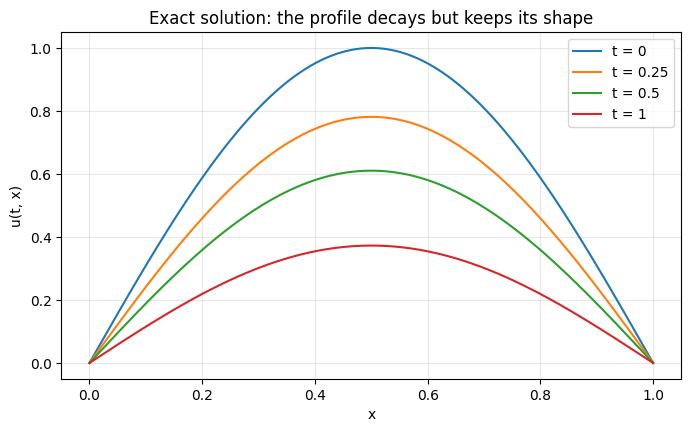

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from pinnlab.solvers.heat import HeatConfig, HeatPINN, heat_exact
from pinnlab.solvers._base import TrainConfig

config = HeatConfig(alpha=0.1, length=1.0, modes=((1, 1.0),))
x = np.linspace(0, 1, 200)

fig, ax = plt.subplots(figsize=(8, 4.5))
for t_slice in (0.0, 0.25, 0.5, 1.0):
    u = heat_exact(np.full_like(x, t_slice), x, config.alpha, config.length, config.modes)
    ax.plot(x, u, label=f"t = {t_slice:g}")
ax.set_xlabel("x"); ax.set_ylabel("u(t, x)")
ax.set_title("Exact solution: the profile decays but keeps its shape")
ax.legend(); ax.grid(alpha=0.3)
plt.show()

<a id="training"></a>
## 2. Training a PINN

`HeatPINN` supplies the residual $u_t - \alpha u_{xx}$, the initial condition and the analytic
solution. The base class handles sampling, the loss and the optimisation, so there is nothing to
write here beyond the configuration.

The loss has three terms — initial condition, boundary condition, PDE residual — and training is
the usual two stages: Adam to get close, then L-BFGS to polish.

In [2]:
solver = HeatPINN(config)

history = solver.train(TrainConfig(
    adam_steps=2000,
    lbfgs_max_iter=150,
    n_f=3000,
    seed=0,
))

for row in history[::2]:
    print(f"step {int(row['step']):5d}   total={row['total']:.3e}   "
          f"ic={row['ic']:.2e}  bc={row['bc']:.2e}  pde={row['pde']:.2e}")

step     1   total=5.454e-01   ic=5.16e-01  bc=2.48e-02  pde=5.07e-03
step  2000   total=3.463e-04   ic=8.74e-05  bc=1.52e-04  pde=1.06e-04


<a id="scoring"></a>
## 3. Scoring it

`relative_l2_error` compares the trained network against the analytic solution on a uniform grid:

$$\frac{\lVert u_{\text{pred}} - u_{\text{exact}} \rVert_2}{\lVert u_{\text{exact}} \rVert_2}$$

This is the number worth quoting. Anything below $10^{-2}$ means the network is tracking the true
solution closely rather than merely looking similar.

> **One run is not a measurement.** The number below comes from a single
> training run, and repeating this notebook with a different seed moves it by a
> factor of two or more.
>
> Across five seeds this configuration has a median relative L2 error of about
> **7e-4**, and the stiffer two-mode case below about **6e-3**. Both spanned
> roughly a 2.5x range between their best and worst seed. Five seeds is a small
> sample, so an individual run — including the one printed below — can land
> outside that range in either direction.
>
> Treat any single figure here as a draw from a distribution, not as *the*
> accuracy of the method. In particular, comparing two configurations on one run
> each cannot resolve a difference smaller than roughly 2x on this problem: a
> mistake worth avoiding, and one this project has made more than once.

In [3]:
error = solver.relative_l2_error()
print(f"Relative L2 error: {error:.3e}")

Relative L2 error: 8.657e-04


<a id="error"></a>
## 4. Where the error lives

An aggregate number hides structure. Plotting the error field shows *where* the network struggles,
which is usually near $t = 0$ where the initial condition and the residual pull against each
other.

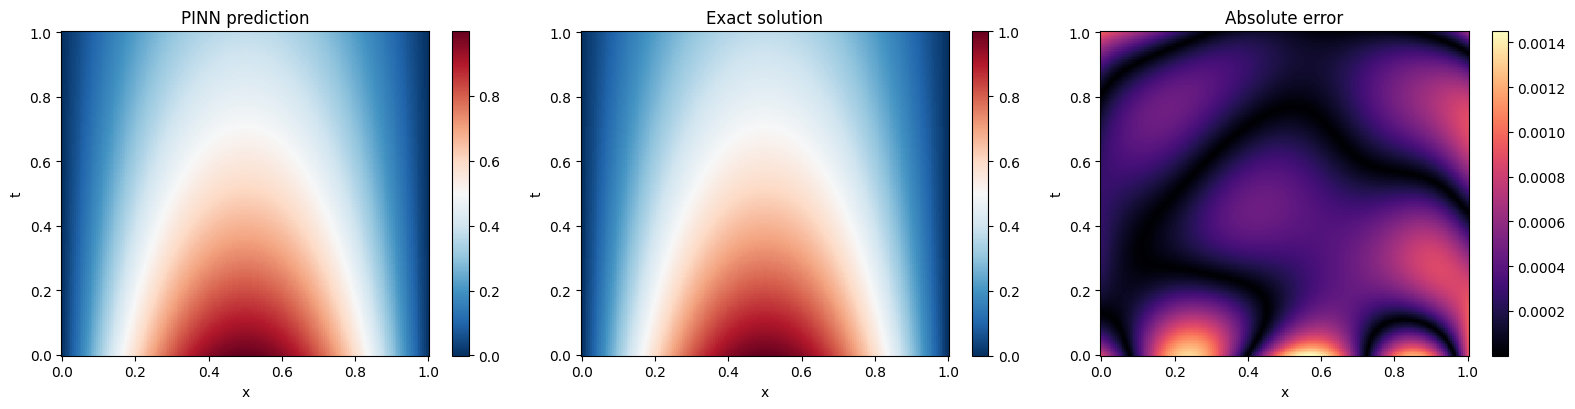

max absolute error: 1.450e-03


In [4]:
tt, xx = solver.evaluation_grid(201, 201)
pred = solver.predict(tt, xx)
exact = heat_exact(tt, xx, config.alpha, config.length, config.modes)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
for ax, field, title, cmap in zip(
    axes,
    (pred, exact, np.abs(pred - exact)),
    ("PINN prediction", "Exact solution", "Absolute error"),
    ("RdBu_r", "RdBu_r", "magma"),
):
    mesh = ax.pcolormesh(xx, tt, field, shading="auto", cmap=cmap)
    fig.colorbar(mesh, ax=ax)
    ax.set_title(title); ax.set_xlabel("x"); ax.set_ylabel("t")
plt.tight_layout(); plt.show()

print(f"max absolute error: {np.abs(pred - exact).max():.3e}")

<a id="stiff"></a>
## 5. A stiffer variant

Now add a fourth mode. Because mode 4 decays 16x faster, the field changes character quickly at
early times and then settles into the fundamental — two time scales in one problem.

Expect a noticeably larger error for the same training budget. That is the honest result, and it is
exactly the kind of gap that motivates Fourier-feature and multi-scale architectures.

In [5]:
stiff_config = HeatConfig(alpha=0.05, length=1.0, modes=((1, 1.0), (4, 0.5)))
stiff = HeatPINN(stiff_config)
stiff.train(TrainConfig(adam_steps=2000, lbfgs_max_iter=150, n_f=3000, seed=0))

stiff_error = stiff.relative_l2_error()
print(f"single mode  : {error:.3e}")
print(f"two modes    : {stiff_error:.3e}")
print(f"ratio        : {stiff_error / error:.1f}x harder")

single mode  : 8.657e-04
two modes    : 2.952e-03
ratio        : 3.4x harder


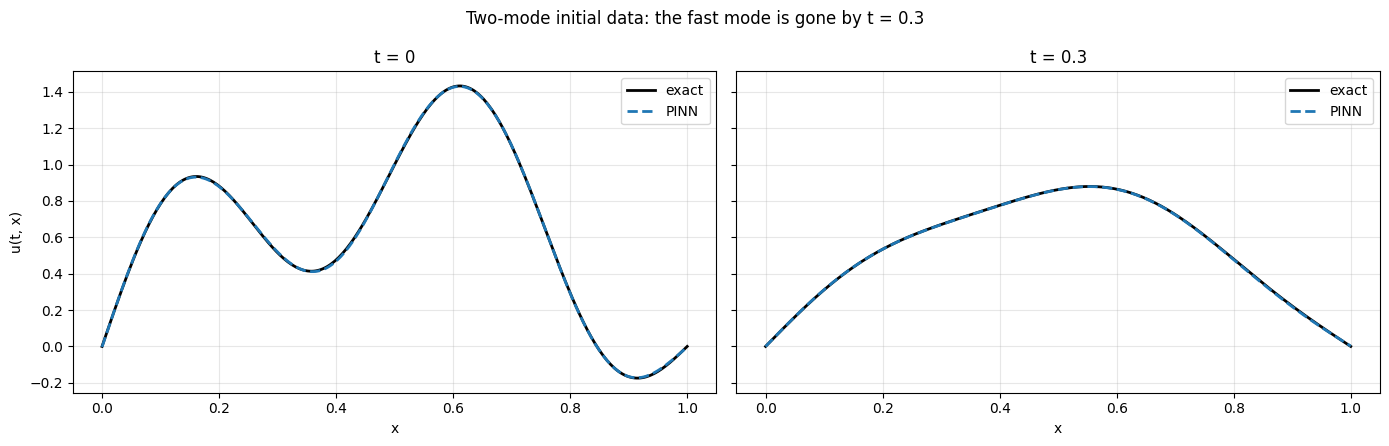

In [6]:
x = np.linspace(0, 1, 300)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True)
for ax, t_slice in zip(axes, (0.0, 0.3)):
    t = np.full_like(x, t_slice)
    ax.plot(x, heat_exact(t, x, stiff_config.alpha, stiff_config.length, stiff_config.modes),
            "k-", lw=2, label="exact")
    ax.plot(x, stiff.predict(t, x), "--", lw=2, label="PINN")
    ax.set_title(f"t = {t_slice:g}"); ax.set_xlabel("x"); ax.legend(); ax.grid(alpha=0.3)
axes[0].set_ylabel("u(t, x)")
plt.suptitle("Two-mode initial data: the fast mode is gone by t = 0.3")
plt.tight_layout(); plt.show()

<a id="takeaways"></a>
## 6. Takeaways

- **A closed-form solution turns a plot into a metric.** `relative_l2_error` is the number to
  report, and the one the test suite asserts on.
- **Stiffness is easy to construct and hard to fit.** Adding one faster-decaying mode measurably
  degrades accuracy at a fixed budget.
- **The residual can be checked without training at all.** Substitute the analytic solution for the
  network and the residual must vanish — see `tests/unit/test_exact_solvers.py`. That separates
  "the physics is wrong" from "the network is under-trained", which a loss curve cannot do.

### Where next

- [`examples/basic/wave_equation.py`](../../examples/basic/wave_equation.py) — second order in
  time, non-decaying, materially harder
- [`examples/advanced/causal_weighting.py`](../../examples/advanced/causal_weighting.py) — temporal
  weighting, with an honest comparison of whether it actually helps
- `pinnlab.solvers.reference.burgers_cole_hopf` — the same treatment for the Burgers benchmark

<div style="background:#0d1117;border-radius:12px;padding:22px 26px;color:#c9d1d9;
            font-family:'Segoe UI',sans-serif;font-size:13px;line-height:1.6;">
  <b style="color:#fff;font-size:15px;">Thanks for reading! 🙌</b><br>
  This notebook is part of the <code>pinnlab</code> example gallery. Explore the companion notebooks in
  <code>notebooks/basic</code>, <code>notebooks/advanced</code>, and <code>notebooks/benchmarks</code>
  for more physics-informed deep-learning recipes.
</div>